In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE

In [8]:
df = pd.read_csv('database.csv')
df.head()

,Player,Team,#,Nation,Position,Age,Minutes,Goals,Assists,Penalty Shoot on Goal,...,Goal-Creating Actions,Passes Completed,Passes Attempted,Pass Completion %,Progressive Passes,Carries,Progressive Carries,Dribble Attempts,Successful Dribbles,Date
0,Bruno Fernandes,Manchester United,8,POR,"FW,AM",29-343,90,0,0,0,...,0,43,60,"71,7",6,50,7,1,1,2024-08-16
1,Marcus Rashford,Manchester United,10,ENG,LW,26-290,90,0,0,0,...,0,22,30,"73,3",2,34,2,6,0,2024-08-16
2,Amad Diallo,Manchester United,16,CIV,RW,22-036,60,0,0,0,...,0,28,33,"84,8",1,22,0,1,1,2024-08-16
3,Alejandro Garnacho,Manchester United,17,ARG,RW,20-046,30,0,1,0,...,1,10,11,"90,9",0,11,2,2,0,2024-08-16
4,Mason Mount,Manchester United,7,ENG,AM,25-219,60,0,0,0,...,0,11,15,"73,3",1,16,0,2,0,2024-08-16


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4270 entries, 0 to 4269
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Player                  4270 non-null   str    
 1   Team                    4270 non-null   str    
 2   #                       4270 non-null   int64  
 3   Nation                  4270 non-null   str    
 4   Position                4270 non-null   str    
 5   Age                     4270 non-null   str    
 6   Minutes                 4270 non-null   int64  
 7   Goals                   4270 non-null   int64  
 8   Assists                 4270 non-null   int64  
 9   Penalty Shoot on Goal   4270 non-null   int64  
 10  Penalty Shoot           4270 non-null   int64  
 11  Total Shoot             4270 non-null   int64  
 12  Shoot on Target         4270 non-null   int64  
 13  Yellow Cards            4270 non-null   int64  
 14  Red Cards               4270 non-null   int64  
 15

In [10]:
df.describe()

,#,Minutes,Goals,Assists,Penalty Shoot on Goal,Penalty Shoot,Total Shoot,Shoot on Target,Yellow Cards,Red Cards,...,Expected Assists (xAG),Shot-Creating Actions,Goal-Creating Actions,Passes Completed,Passes Attempted,Progressive Passes,Carries,Progressive Carries,Dribble Attempts,Successful Dribbles
count,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,...,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000,4270.000000
mean,16.780094,64.775410,0.094145,0.071194,0.005855,0.007260,0.868384,0.296019,0.161593,0.004918,...,0.072482,1.548946,0.166276,26.152927,32.061593,2.456206,22.330445,1.236300,1.215925,0.533255
std,12.215586,31.251815,0.326883,0.271362,0.085014,0.092814,1.241323,0.625048,0.373803,0.069964,...,0.167391,1.856990,0.458118,20.604004,22.945436,2.745780,16.012547,1.760593,1.742428,0.963710
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,13.000000,0.000000,10.000000,0.000000,0.000000,0.000000
50%,15.000000,82.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,22.000000,29.000000,2.000000,20.000000,1.000000,1.000000,0.000000
75%,24.000000,90.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.100000,2.000000,0.000000,38.000000,46.000000,4.000000,31.000000,2.000000,2.000000,1.000000
max,87.000000,90.000000,4.000000,3.000000,3.000000,3.000000,8.000000,5.000000,2.000000,1.000000,...,1.600000,16.000000,6.000000,127.000000,140.000000,30.000000,106.000000,18.000000,16.000000,12.000000


In [11]:
df.isnull().sum()

Player                     0
Team                       0
#                          0
Nation                     0
Position                   0
Age                        0
Minutes                    0
Goals                      0
Assists                    0
Penalty Shoot on Goal      0
Penalty Shoot              0
Total Shoot                0
Shoot on Target            0
Yellow Cards               0
Red Cards                  0
Touches                    0
Dribbles                   0
Tackles                    0
Blocks                     0
Expected Goals (xG)        0
Non-Penalty xG (npxG)      0
Expected Assists (xAG)     0
Shot-Creating Actions      0
Goal-Creating Actions      0
Passes Completed           0
Passes Attempted           0
Pass Completion %         46
Progressive Passes         0
Carries                    0
Progressive Carries        0
Dribble Attempts           0
Successful Dribbles        0
Date                       0
dtype: int64

In [ ]:
# Convertendo a coluna 'Date' para datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Converter a coluna 'Age' para numérica
df['Age'] = df['Age'].astype(str).str.extract('(\d+)').astype(float)

# Converto a coluna 'Pass Completion' para numérica
df['Pass Completion %'] = (
    df['Pass Completion %']
    .astype(str)
    .str.replace(',', '.')
    .str.rstrip('%')
    .astype(float)
)

# Completando os valores faltantes 
df['Pass Completion %'].fillna(
    df['Pass Completion %'].mean(),
    inplace=True
)

0       71.7
1       73.3
2       84.8
3       90.9
4       73.3
        ... 
4265    90.9
4266    64.7
4267    80.0
4268    78.9
4269    90.6
Name: Pass Completion %, Length: 4270, dtype: float64

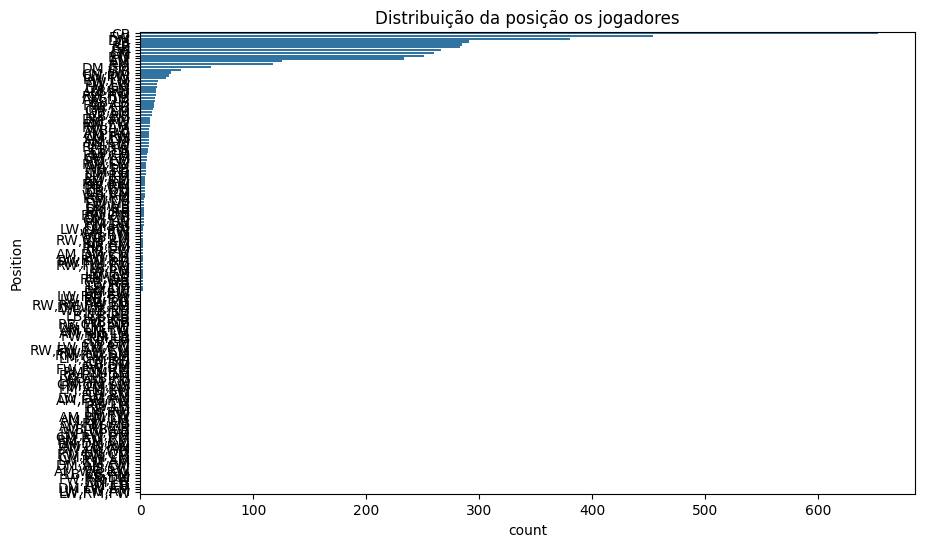

In [20]:
# Fazendo a distribuição da posição dos jogadores
plt.figure(figsize=(10, 6))
sns.countplot(y='Position', data=df, order=df['Position'].value_counts().index)
plt.title('Distribuição da posição os jogadores')
plt.show()

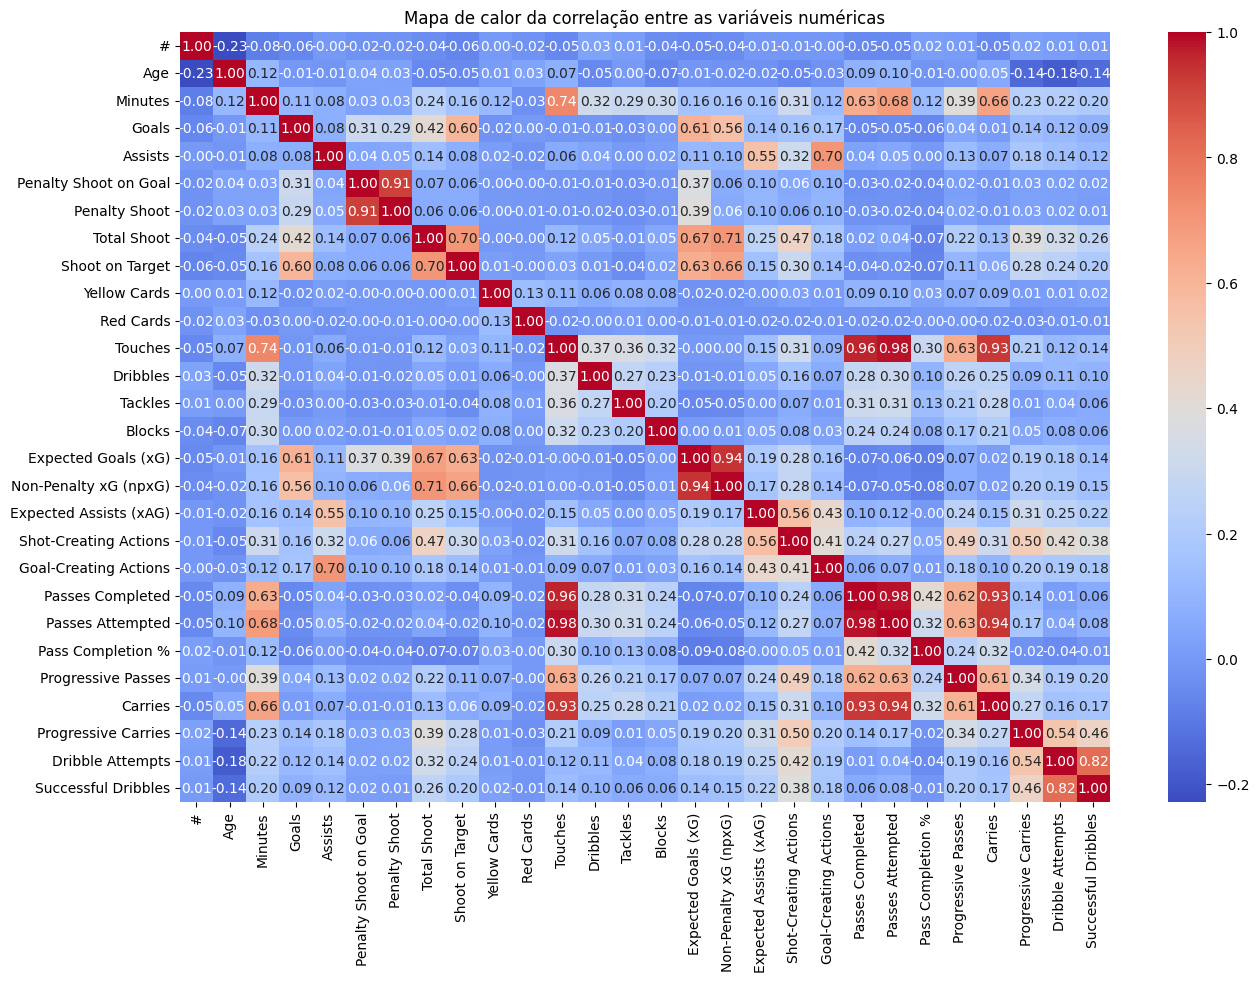

In [22]:
# Correlação do mapa de calor
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Mapa de calor da correlação entre as variáveis numéricas')
plt.show()

In [ ]:
# Criando uma nova feature de "Contribuição de gols" que é a soma de gols e assitencias
df['Goal Contribution'] = df['Goals'] + df['Assists']

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Definindo features e target
features = ['Minutes', 'Goals', 'Assists', 'Touches', 'Passes Completed', 'Pass Completion %']
target = 'Goal Contribution'

# Dividir os dados em treino e teste
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar o modelo de regressão Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predizer e avaliar o modelo
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
rmse

np.float64(0.006599978709780435)

In [ ]:
'''O modelo Random Forest Regressor apresentou um RMSE de aproximadamente 0.0066, indicando baixo erro 
médio entre os valores previstos e os valores reais da variável alvo “Goal Contribution”. 
Quanto menor o RMSE, melhor o desempenho preditivo do modelo.
Foram utilizadas as seguintes features para prever a contribuição de gols: 'Minutes', 'Goals', 'Assists', 'Touches', 'Passes Compleated', 'Pass Completion %'.
'''